# plotting PCAs

This notebook generate PCA plots for Single Cell datasets

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "tidyr", "circlize")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

In [2]:
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()
    
    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    
    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    
    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")

Git root directory: /Users/kaylorhuang/Documents/GitHub_Repos/Kaylor---NF1_organoid_profile_analysis 


In [ ]:
# Load PCA results
max_projection_2D_sc_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/2D/max_projection/sc_fs_pca.parquet"))
head(max_projection_2D_sc_pca_results)
# Recode STAURO to Staurosporine in the data
max_projection_2D_sc_pca_results <- max_projection_2D_sc_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

sc_3D_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/3D/sc_fs_pca.parquet"))
sc_3D_pca_results <- sc_3D_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

middle_slice_2D_sc_pca_results <- arrow::read_parquet(file.path(root_dir,"1.EDA/results/pca/2D/middle_slice/sc_fs_pca.parquet"))
middle_slice_2D_sc_pca_results <- middle_slice_2D_sc_pca_results %>%
    mutate(Metadata_treatment = ifelse(Metadata_treatment == "STAURO", "Staurosporine", Metadata_treatment))

Metadata_WellRow,Metadata_WellCol,Metadata_Well,Metadata_treatment,Metadata_dose,Metadata_unit,Metadata_Treatment,Metadata_Target,Metadata_Class,Metadata_Therapeutic_Categories,⋯,Metadata_Plate,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_patient_tumor,Metadata_patient,Metadata_tumor,PC1,PC2
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
C,2,C2,Staurosporine,10,nM,Staurosporine,Apoptosis induction,Small Molecule,Experimental,⋯,NF0014,1,1,1,1,NF0014_T1,NF0014,T1,40.61918,85.95229
C,2,C2,Staurosporine,10,nM,Staurosporine,Apoptosis induction,Small Molecule,Experimental,⋯,NF0014,2,2,2,2,NF0014_T1,NF0014,T1,34.61347,62.77473
C,2,C2,Staurosporine,10,nM,Staurosporine,Apoptosis induction,Small Molecule,Experimental,⋯,NF0014,3,3,3,3,NF0014_T1,NF0014,T1,37.38104,76.50676
C,2,C2,Staurosporine,10,nM,Staurosporine,Apoptosis induction,Small Molecule,Experimental,⋯,NF0014,4,4,4,4,NF0014_T1,NF0014,T1,44.57985,71.61665
C,2,C2,Staurosporine,10,nM,Staurosporine,Apoptosis induction,Small Molecule,Experimental,⋯,NF0014,5,5,5,5,NF0014_T1,NF0014,T1,55.06849,93.97084
C,2,C2,Staurosporine,10,nM,Staurosporine,Apoptosis induction,Small Molecule,Experimental,⋯,NF0014,6,6,6,6,NF0014_T1,NF0014,T1,37.00110,82.78256


Metadata_patient_tumor,Metadata_patient_id,Metadata_patient,Metadata_tumor,Metadata_object_id,Metadata_unit,Metadata_dose,Metadata_treatment,Metadata_Target,Metadata_Class,⋯,Metadata_Well,Metadata_parent_organoid,Metadata_cqc.organoid_flagged,Metadata_cqc.nan_detected,Metadata_cqc.missing_parent_organoid,Metadata_cqc.small_nuclei_outlier,Metadata_cqc.large_nuclei_outlier,Metadata_cqc.mass_displacement_outlier,PC1,PC2
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>
NF0014_T1,NF0014_T1,NF0014,T1,61,uM,1,Fimepinostat,PI3K and HDAC inhibitor,Small Molecule,⋯,E5,-1,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,67.19816,-18.793378
NF0014_T1,NF0014_T1,NF0014,T1,114,uM,1,Fimepinostat,PI3K and HDAC inhibitor,Small Molecule,⋯,E5,-1,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,67.14162,-19.066191
NF0014_T1,NF0014_T1,NF0014,T1,184,uM,1,Fimepinostat,PI3K and HDAC inhibitor,Small Molecule,⋯,E5,-1,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,66.95808,-18.636273
NF0014_T1,NF0014_T1,NF0014,T1,255,uM,1,Fimepinostat,PI3K and HDAC inhibitor,Small Molecule,⋯,E5,-1,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,67.17815,-18.638683
NF0014_T1,NF0014_T1,NF0014,T1,54,uM,1,Fimepinostat,PI3K and HDAC inhibitor,Small Molecule,⋯,D5,-1,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,67.09701,-9.237756
NF0014_T1,NF0014_T1,NF0014,T1,54,uM,1,Fimepinostat,PI3K and HDAC inhibitor,Small Molecule,⋯,D5,-1,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,67.09701,-9.237756


Metadata_WellRow,Metadata_WellCol,Metadata_Well,Metadata_treatment,Metadata_dose,Metadata_unit,Metadata_Treatment,Metadata_Target,Metadata_Class,Metadata_Therapeutic_Categories,⋯,Metadata_Plate,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_patient_tumor,Metadata_patient,Metadata_tumor,PC1,PC2
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>
C,2,C2,Staurosporine,10,nM,Staurosporine,Apoptosis induction,Small Molecule,Experimental,⋯,NF0014,1,1,2,2,NF0014_T1,NF0014,T1,65.2934081,-57.292393
C,2,C2,Staurosporine,10,nM,Staurosporine,Apoptosis induction,Small Molecule,Experimental,⋯,NF0014,2,2,3,3,NF0014_T1,NF0014,T1,77.2275267,-51.637820
C,2,C2,Staurosporine,10,nM,Staurosporine,Apoptosis induction,Small Molecule,Experimental,⋯,NF0014,3,3,4,4,NF0014_T1,NF0014,T1,88.3944010,-82.857331
D,2,D2,Digoxin,1,uM,Digoxin,Na+/K+ pump inhibitor,Small Molecule,Cardiac Glycosides,⋯,NF0014,1,1,2,2,NF0014_T1,NF0014,T1,-19.3282796,-21.429247
D,2,D2,Digoxin,1,uM,Digoxin,Na+/K+ pump inhibitor,Small Molecule,Cardiac Glycosides,⋯,NF0014,3,3,4,4,NF0014_T1,NF0014,T1,0.4222417,3.679493
D,2,D2,Digoxin,1,uM,Digoxin,Na+/K+ pump inhibitor,Small Molecule,Cardiac Glycosides,⋯,NF0014,4,4,5,5,NF0014_T1,NF0014,T1,8.0801051,1.672478


In [31]:
# Set custom colors for each treatment
custom_treatment_palette <- c(
    'DMSO' = "#5a5c5d",              # Control - gray
    'Staurosporine' = "#7D2780",     # Dark purple
    
    'Fimepinostat' = "#1E6B61",      # Teal (HDAC inhibitor)
    'Copanlisib' = "#0092E0",        # Blue (PI3K inhibitor)
    
    'Imatinib' = "#576A20",          # Olive green
    'Nilotinib' = "#646722",         # Yellow-green
    'Cabozantinib' = "#758B2D",      # Light olive
    
    'Everolimus' = "#ACE089",        # Light green (mTOR inhibitor)
    'Rapamycin' = "#90D070",         # Medium green (mTOR inhibitor)
    'Linsitinib' = "#ACE040",        # Yellow-green (IGF-1R inhibitor)
    
    'Onalespib' = "#33206A",         # Dark purple (HSP90 inhibitor)
    'Digoxin' = "#A16C28",           # Orange-brown
    'Ketotifen' = "#3A8F00",         # Green
    
    'Binimetinib' = "#ff0000",       # Red (MEK inhibitor)
    'Mirdametinib' = "#cc0000",      # Dark red (MEK inhibitor)
    'Trametinib' = "#ff3333",        # Light red (MEK inhibitor)
    'Selumetinib' = "#ff6666"        # Lighter red (MEK inhibitor)
)

In [32]:
umap_theme <- theme(
        plot.title = element_text(hjust = 0.5, size = 16),
        axis.title.x = element_text(size = 14),
        axis.title.y = element_text(size = 14),
        legend.title = element_text(size = 14, hjust = 0.5),
        legend.text = element_text(size = 12)
    )

2D MIP PCA

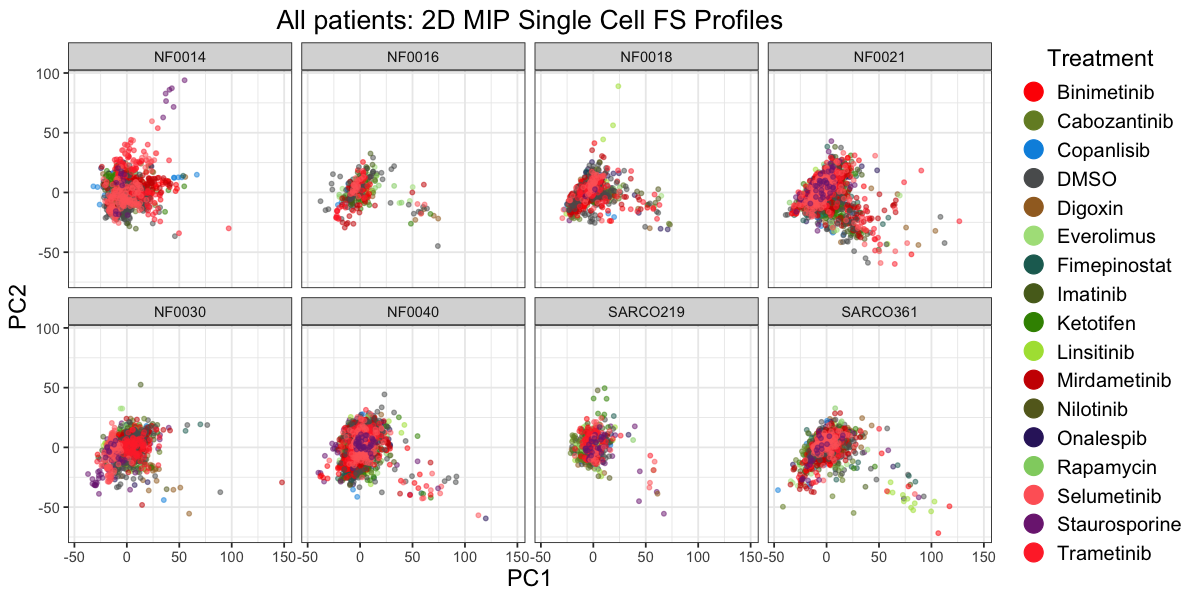

In [ ]:
# Define the output path for figures
figures_path <- file.path(root_dir, "1.EDA/figures/pca/2D/max_projection")  
# Create the directory if it doesn't exist
dir.create(figures_path, showWarnings = FALSE, recursive = TRUE)

width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(max_projection_2D_sc_pca_results, aes(x = PC1, y = PC2, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D MIP Single Cell FS Profiles", x = "PC1", y = "PC2")
    + theme_bw()
    + umap_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
    + facet_wrap(~Metadata_patient, nrow = 2)
)
pca_2d_sc_mip_faceted_path <- file.path(figures_path, "all_patients_2D_MIP_pca_sc_features_facet_by_patient.png")
ggsave(pca_sc_plot, file = pca_2d_sc_mip_faceted_path, width = width, height = height, dpi = 300)
pca_sc_plot

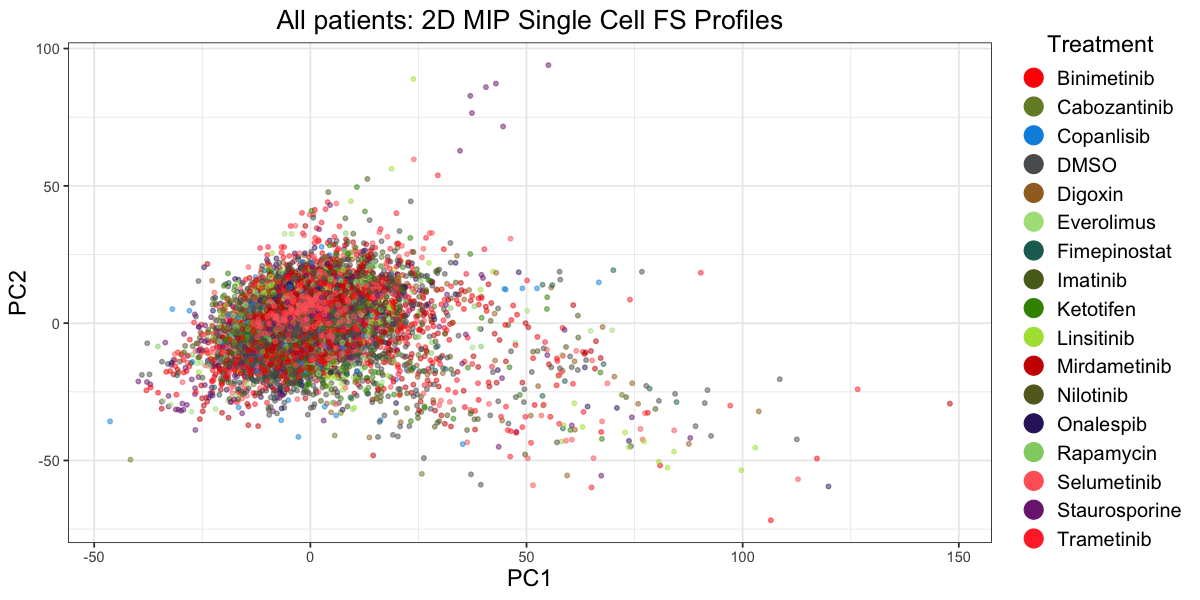

In [ ]:
# Define the output path for figures
figures_path <- file.path(root_dir, "1.EDA/figures/pca/2D/max_projection")  
# Create the directory if it doesn't exist
dir.create(figures_path, showWarnings = FALSE, recursive = TRUE)

width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(max_projection_2D_sc_pca_results, aes(x = PC1, y = PC2, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D MIP Single Cell FS Profiles", x = "PC1", y = "PC2")
    + theme_bw()
    + umap_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_2d_sc_mip_path <- file.path(figures_path, "all_patients_2D_MIP_pca_sc_features.png")
ggsave(pca_sc_plot, file = pca_2d_sc_mip_path, width = width, height = height, dpi = 300)
pca_sc_plot

2D Middle Slice

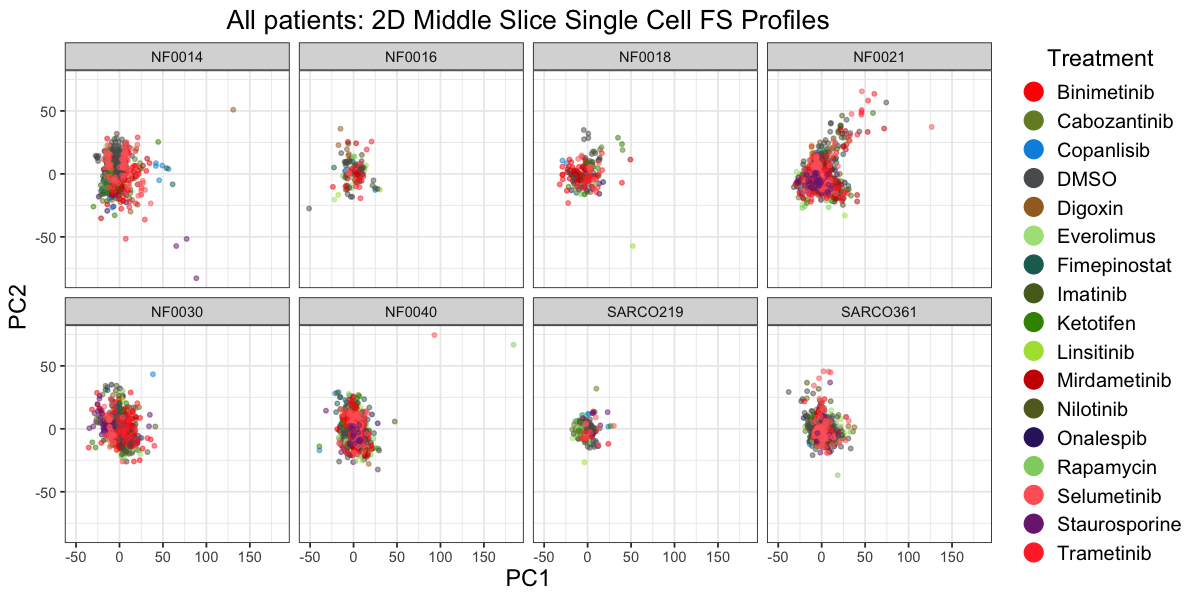

In [ ]:
# Define the output path for figures
figures_path <- file.path(root_dir, "1.EDA/figures/pca/2D/middle_slice")  
# Create the directory if it doesn't exist
dir.create(figures_path, showWarnings = FALSE, recursive = TRUE)

width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(middle_slice_2D_sc_pca_results, aes(x = PC1, y = PC2, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D Middle Slice Single Cell FS Profiles", x = "PC1", y = "PC2")
    + theme_bw()
    + umap_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
    + facet_wrap(~Metadata_patient, nrow = 2)
)
pca_2d_sc_middle_slice_faceted_path <- file.path(figures_path, "all_patients_2D_middle_slice_pca_sc_features_facet_by_patient.png")
ggsave(pca_sc_plot, file = pca_2d_sc_middle_slice_faceted_path, width = width, height = height, dpi = 300)
pca_sc_plot

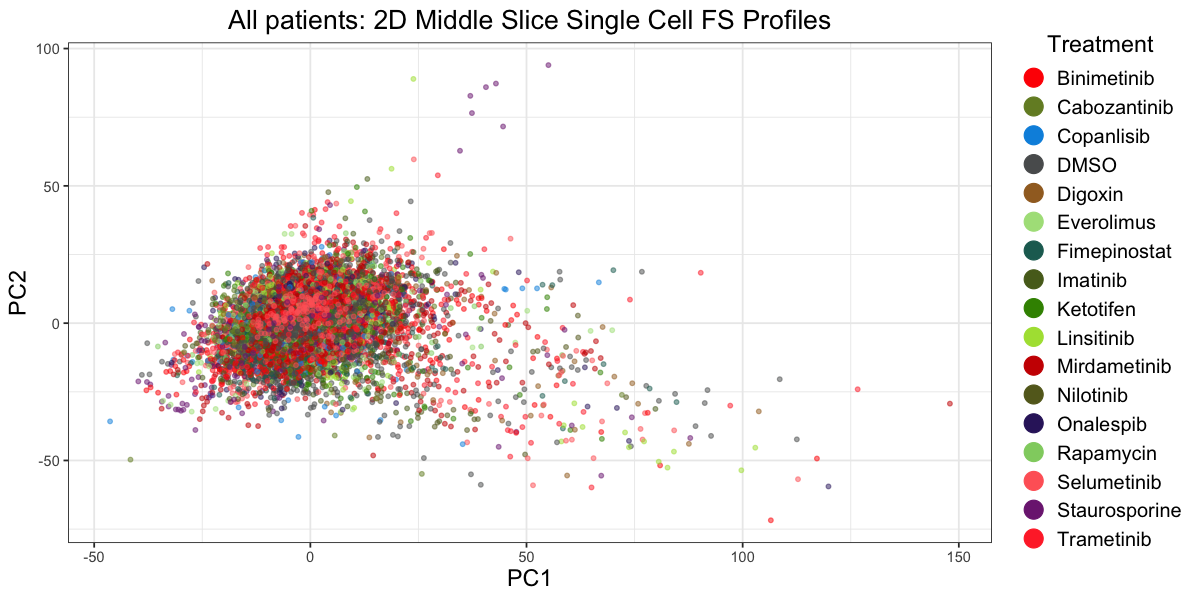

In [ ]:
# Define the output path for figures
figures_path <- file.path(root_dir, "1.EDA/figures/pca/2D/middle_slice")  
# Create the directory if it doesn't exist
dir.create(figures_path, showWarnings = FALSE, recursive = TRUE)

width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(max_projection_2D_sc_pca_results, aes(x = PC1, y = PC2, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 2D Middle Slice Single Cell FS Profiles", x = "PC1", y = "PC2")
    + theme_bw()
    + umap_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_2d_sc_middle_slice_path <- file.path(figures_path, "all_patients_2D_middle_slice_pca_sc_features.png")
ggsave(pca_sc_plot, file = pca_2d_sc_middle_slice_path, width = width, height = height, dpi = 300)
pca_sc_plot

3D PCA

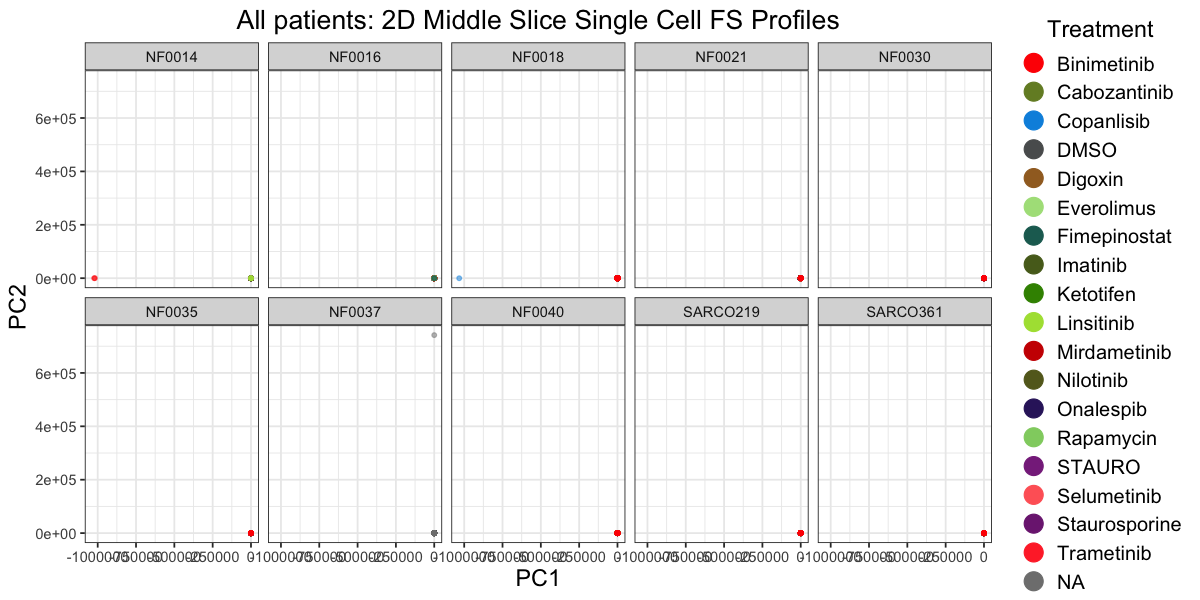

In [ ]:
# Define the output path for figures
figures_path <- file.path(root_dir, "1.EDA/figures/pca/3D")  
# Create the directory if it doesn't exist
dir.create(figures_path, showWarnings = FALSE, recursive = TRUE)

width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(sc_3D_pca_results, aes(x = PC1, y = PC2, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 3D Single Cell FS Profiles", x = "PC1", y = "PC2")
    + theme_bw()
    + umap_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
    + facet_wrap(~Metadata_patient, nrow = 2)
)
pca_3d_sc_faceted_path <- file.path(figures_path, "all_patients_3D_sc_features_facet_by_patient.png")
ggsave(pca_sc_plot, file = pca_3d_sc_faceted_path, width = width, height = height, dpi = 300)
pca_sc_plot

In [ ]:
# Define the output path for figures
figures_path <- file.path(root_dir, "1.EDA/figures/pca/3D")  
# Create the directory if it doesn't exist
dir.create(figures_path, showWarnings = FALSE, recursive = TRUE)

width <- 10
height <- 5
options(repr.plot.width = width, repr.plot.height = height)
pca_sc_plot <- (
    ggplot(max_projection_2D_sc_pca_results, aes(x = PC1, y = PC2, color = Metadata_treatment))
    + geom_point(alpha = 0.5, size = 1)
    + scale_color_manual(values = custom_treatment_palette)
    + labs(title = "All patients: 3D MIP Single Cell FS Profiles", x = "PC1", y = "PC2")
    + theme_bw()
    + umap_theme

    + guides(
        color = guide_legend(
            title = "Treatment",
            override.aes = list(alpha = 1, size = 5),
            ncol = 1
        )
    )
)
pca_3d_sc_path <- file.path(figures_path, "all_patients_3D_pca_sc_features.png")
ggsave(pca_sc_plot, file = pca_3d_sc_path, width = width, height = height, dpi = 300)
pca_sc_plot